In [1]:
import json
from pathlib import Path

import observe
from matplotlib import pyplot as plt

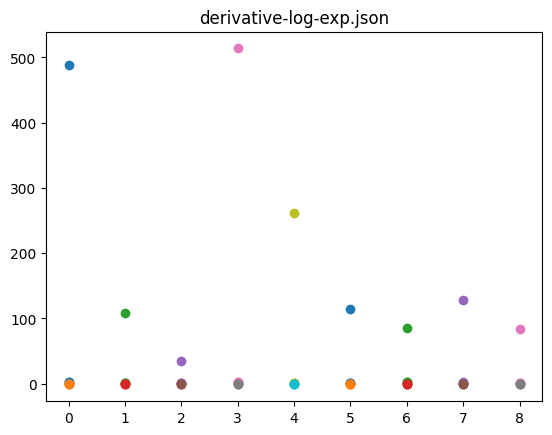

derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
derivative-radial.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'


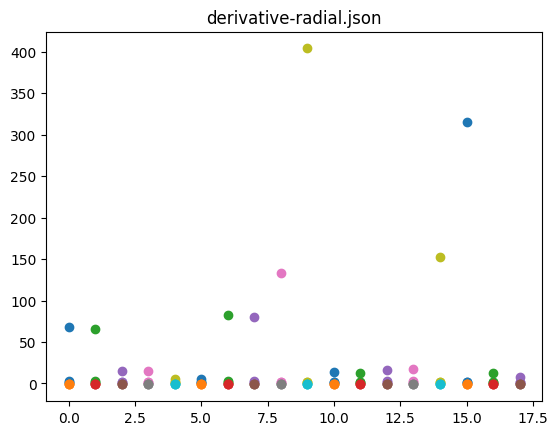

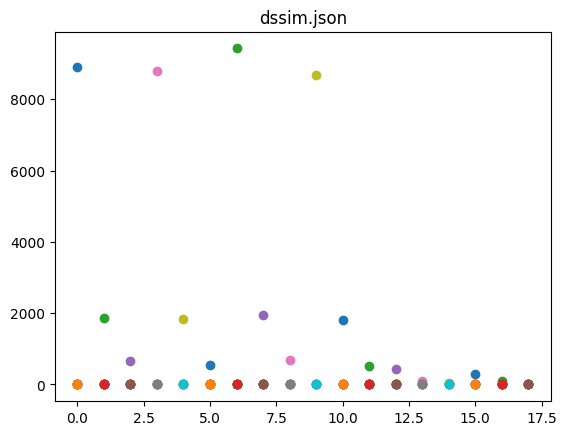

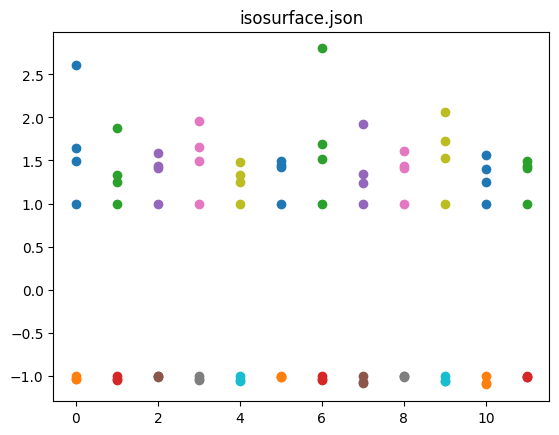

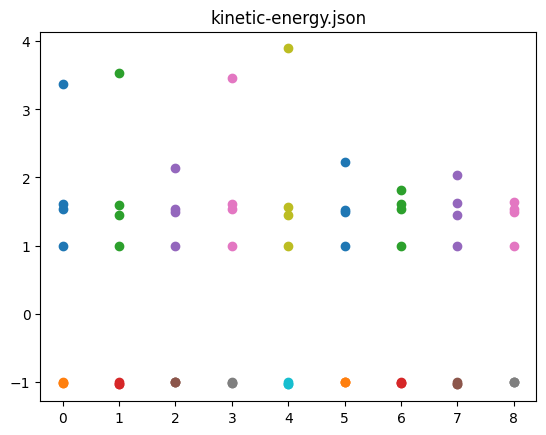

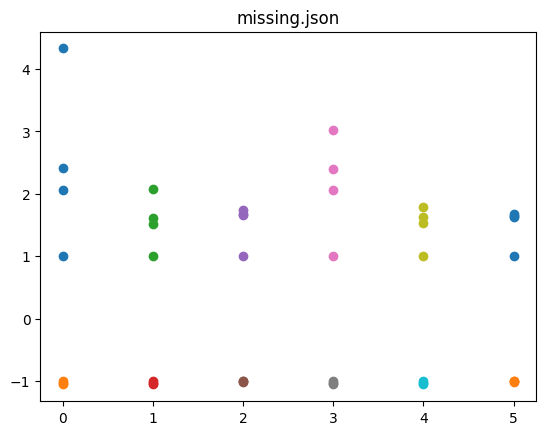

nan.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
nan.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
nan.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
nan.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'


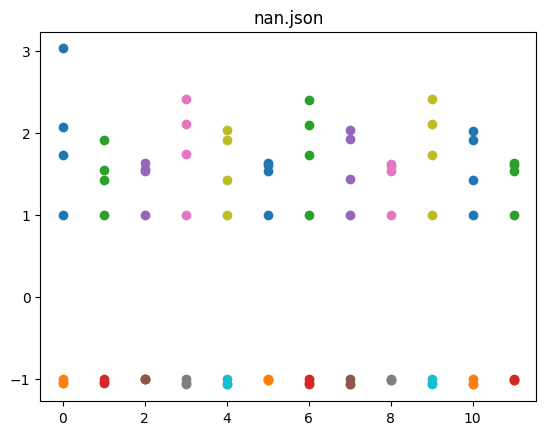

precipitation.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
precipitation.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'


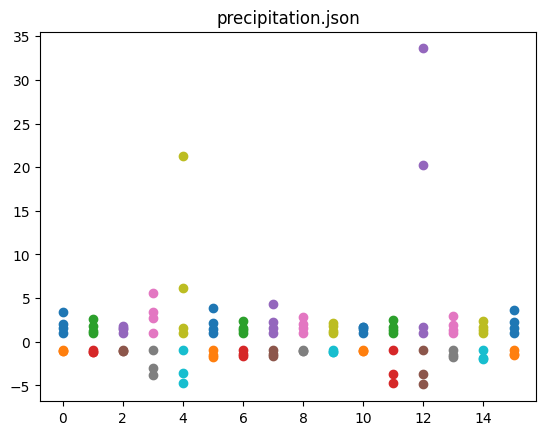

specific-humidity-log10.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
specific-humidity-log10.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'
specific-humidity-log10.json 'eca24ca40408da949e93b4419ddc106c80f8bbc2d8e735475a0e52248b52ece7'


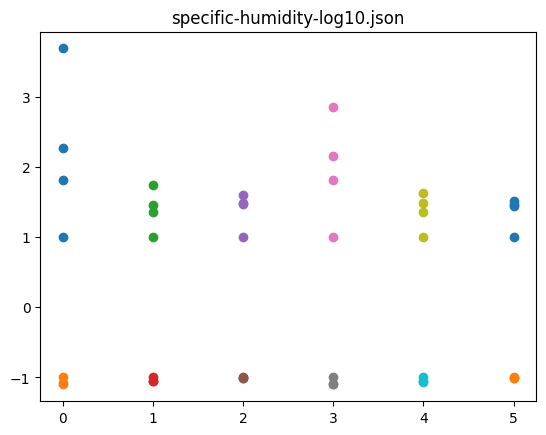

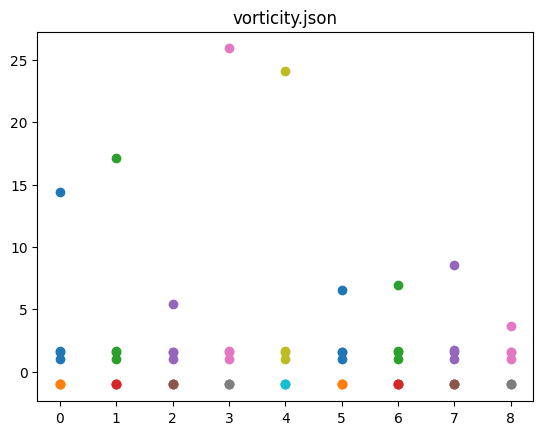

In [2]:
for name in [
    "derivative-log-exp.json",
    "derivative-radial.json",
    "dssim.json",
    "isosurface.json",
    "kinetic-energy.json",
    "missing.json",
    "nan.json",
    "precipitation.json",
    "specific-humidity-log10.json",
    "vorticity.json",
]:
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    fig, ax = plt.subplots()

    ax.set_title(name)

    i = 0

    for result in observations:
        if result["codec"]["id"] != "safeguards":
            continue

        if result["codec"]["codec"]["id"] == "zero":
            continue

        assert result["codec"]["lossless"]["for_codec"] is None

        try:
            (safeguarded_encode_timing,) = result["encode_timing"][
                observe.json_hash(result["codec"])
            ]
            (codec_encode_encode_timing,) = result["encode_timing"][
                observe.json_hash(result["codec"]["codec"])
            ]
            codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
                observe.json_hash(result["codec"]["codec"])
            ]
            (lossless_for_corrections_encode_timing,) = result["encode_timing"][
                observe.json_hash(result["codec"]["lossless"]["for_corrections"])
            ]

            (safeguarded_decode_timing,) = result["decode_timing"][
                observe.json_hash(result["codec"])
            ]
            (lossless_for_corrections_decode_timing,) = result["decode_timing"][
                observe.json_hash(result["codec"]["lossless"]["for_corrections"])
            ]
        except Exception as err:
            print(name, err)
            continue

        ax.scatter(
            [i, i, i, i],
            [
                1.0,
                (codec_encode_encode_timing + codec_encode_decode_timing)
                / codec_encode_encode_timing,
                (
                    codec_encode_encode_timing
                    + codec_encode_decode_timing
                    + lossless_for_corrections_encode_timing
                )
                / codec_encode_encode_timing,
                safeguarded_encode_timing / codec_encode_encode_timing,
            ],
        )
        ax.scatter(
            [i, i, i],
            [
                -1.0,
                -(codec_decode_timing + lossless_for_corrections_decode_timing)
                / codec_decode_timing,
                -safeguarded_decode_timing / codec_decode_timing,
            ],
        )

        i += 1

    plt.show()